<a href="https://colab.research.google.com/github/muhammad-usman-tech/HMEQ-Loan-Default-EDA-and-Data-Analysis/blob/main/lab_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


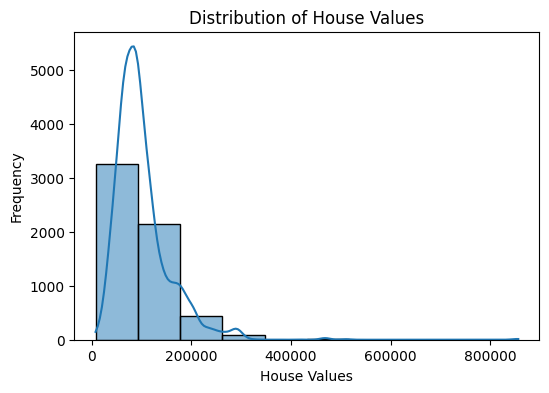

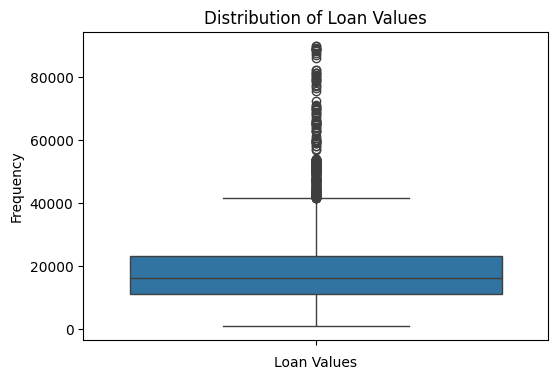

/tmp/ipykernel_2582/3106438633.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_collect['gender'] = np.random.choice(['Male', 'Female'], size=len(df_collect),p=[0.40, 0.60])


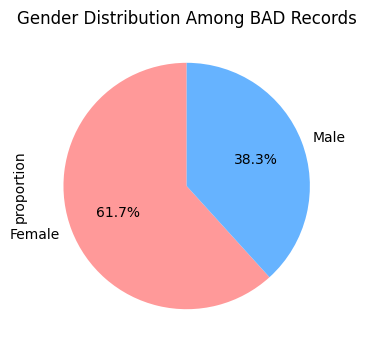

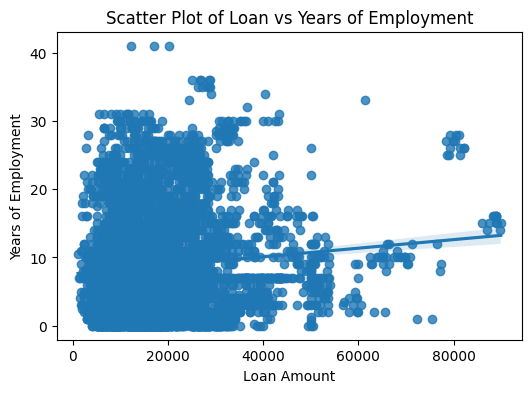

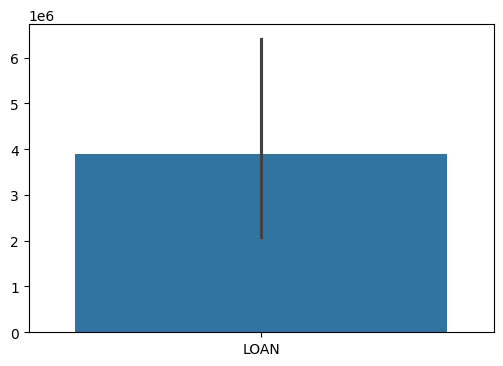

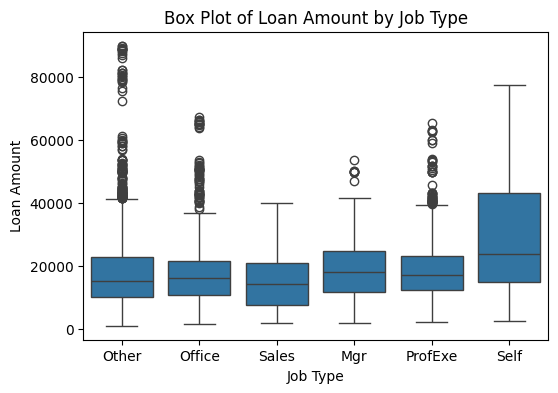

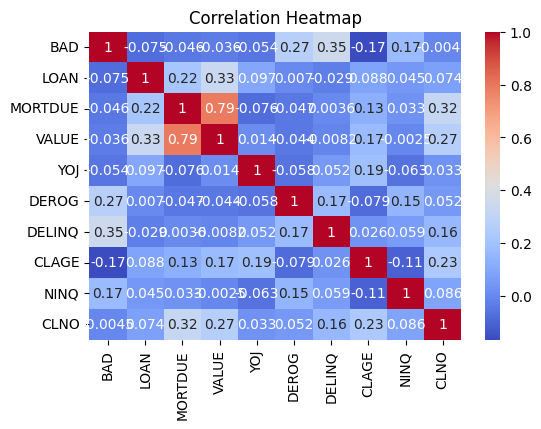

Other
Other
0    Other
Name: JOB, dtype: object
0    Other
Name: JOB, dtype: object
Most common loan reason:
REASON
DebtCon    4180
HomeImp    1780
Name: count, dtype: int64

Loan reason among defaulters:
Default rate with derogatory reports:
DEROG
0     0.16
1     0.39
2     0.51
3     0.74
4     0.78
5     0.47
6     0.67
7     1.00
8     1.00
9     1.00
10    1.00
Name: BAD, dtype: float64


In [ ]:
from numpy._core import numeric
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: dataset loaded
df=pd.read_csv('hmeq.csv')
# Step 2: inspecting the dataset
df.info() #data types of the columns are looking little good
df.shape #(5960, 13)  # can say a wide format data set
df.head() # good data
df.describe() #max derog is 10 means this person must not be able to take the further loan
df.dtypes #types seems good only reason and the job is in the object and the other thing some columns that must show the exect numbers in int like number of bad reviews are also some in the float (little new for me)


# Task:3
# removing duplicates:

df=df.drop_duplicates()
df.shape #again got 5960 means no duplicated exists

#missing values
missing_val=df.isnull().sum()
percentage=(missing_val/len(df))*100
percentage
to_drop=percentage[percentage>=20].index
df=df.drop(columns=to_drop)
percentage=(df.isnull().sum()/len(df))*100
percentage

columns_to_median=df.select_dtypes(include=['number']).columns
columns_to_median
df[columns_to_median]=df[columns_to_median].fillna(df[columns_to_median].median())
df_object=df.select_dtypes(include=['object']).columns

df[df_object]=df[df_object].fillna(df[df_object].mode().iloc[0])

df_null_test=df.isnull().sum()
df_null_test # got all 0

# data types were looking godd so no need to change or correct them just told you about the DEROG expects number of bad reviews must not in the float
df['DEROG']=df['DEROG'].astype(int)
df['BAD']=df['BAD'].astype(int)

# Step 4 univariate analysis: single variable analysis eg histogram
# making hist for vlue of the houses
plt.figure(figsize=(6,4))
sns.histplot(df['VALUE'],bins=10,kde=True)
plt.title('Distribution of House Values')
plt.xlabel('House Values')
plt.ylabel('Frequency')
plt.show()#0 percent sekewed on left side and littleright sekewed on right side

# box plot for the loan values by the users like they demanded for
plt.figure(figsize=(6,4))
sns.boxplot(y=df['LOAN'],data=df)
plt.title('Distribution of Loan Values')
plt.xlabel('Loan Values')
plt.ylabel('Frequency')
plt.show()# actually a neat and wide box plot but have alot of outliers (max is 40 thousand) after 40 thousand
df['DEROG'].max() # not good for the pie chart

df_collect=df[df['BAD']==1]
df_collect['gender'] = np.random.choice(['Male', 'Female'], size=len(df_collect),p=[0.40, 0.60])
df_collect['gender'].value_counts()
df_pie = df_collect['gender'].value_counts(normalize=True) * 100

df_pie

plt.figure(figsize=(6,4))
import matplotlib.pyplot as plt

# Plot the pie chart
df_pie.plot(
    kind='pie',
    autopct='%1.1f%%',     # Displays the percentage value on each slice
    startangle=90,         # Rotates the chart for a cleaner look
    colors=['#ff9999','#66b3ff'] # Optional: Nice pink/blue colors
)

# Clean up the chart display
plt.title("Gender Distribution Among BAD Records")
plt.show()

df['BAD'].value_counts()
# step 5 bivariate analysis means graphs using 2 variable like scatter,pairplot
# scatter plot
plt.figure(figsize=(6,4))
sns.regplot(x=df['LOAN'],y=df['YOJ'],data=df)
plt.title('Scatter Plot of Loan vs Years of Employment')
# checking if the number of greater year of employees are applying for much or less or less exp emp are applying for much exp or not
plt.xlabel('Loan Amount')
plt.ylabel('Years of Employment')
plt.show() #found no relation ship between them means any years of exp employee is applying any limit of amount
# may be according to their salary


# bar chart
df_bar=df[df['BAD']==1]
#taking onl the people who have not paid loan yet their job type
display=df_bar.groupby('JOB')['LOAN'].sum().reset_index()
display=display.sort_values(by='LOAN',ascending=False)
display
plt.figure(figsize=(6,4))
sns.barplot(display.head(5))
plt.show() # not making correct chart

# pending amount by job
# box plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['JOB'],y=df['LOAN'],data=df)
plt.title('Box Plot of Loan Amount by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Loan Amount')
plt.show() #people with "other" job type have max outlier is greater then 80000 and most of the job type if OTHER

# Task 6 :finding corelation
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# while value vs mortude has max 0.79 positive relation mean's if value is increasing the left amount to pay(mortude is still big amount left)


# Task-7: data drilling

# finding the most jobs who got bad or who got good review
df_bad=df[df['BAD']==1]
df_good=df[df['BAD']==0]
# most job by the people who paid the job:after knowing this job is some one comes later we can prefer that person and do not prefor that person's job in the mood on people who didnt pay or got bad==1

bad_job=df_bad['JOB'].mode()[0]
good_job=df_good['JOB'].mode()[0]
print('==========')
print(good_job)
print(bad_job)
# both got the output is "other"
# definately if i will check the overall job that will also the 'ohter' so here i failed to get any use full data
# but wait getting the 2nd most job
bad2_job=df_bad['JOB'].mode(1)
good2_job=df_good['JOB'].mode(1)
print('==========')
print(good2_job)
print(bad2_job) #again got other still failed

# step 8 finding the outlier using the z-score
df['DELINQ_zscore']=np.abs(stats.zscore(df['DELINQ']))
df['DEROG_zscore']=np.abs(stats.zscore(df['DEROG']))
df['LOAN_zscore']=np.abs(stats.zscore(df['LOAN']))

df_next_cleaned=df[(df['DELINQ_zscore']<=3)  & (df['DEROG_zscore']<=3)  & (df['LOAN_zscore']<=3)]

# step 9: data mining : finding patterns and applying the anomalies
print("Most common loan reason:")
print(df['REASON'].value_counts())

print("\nLoan reason among defaulters:")
# print(bad_loans['REASON'].value_counts())

print("Default rate with derogatory reports:")
print(df.groupby('DEROG')['BAD'].mean().round(2))


# at last very difficult data set very difficult and very diff columns even at the last i don't know the meaning or reasons of the columns name except one or two or may be 3 which i used in the steps
